# Restaurant & Café Sales Trend Analysis
## Phase 3 — Combined Weather and Festivities 

**Author:** Carl Mark Sibal

**Tools:** Python, Pandas, Matplotlib, Seaborn, Requests

**Dataset Sources:** Balaji Fast Food Sales (India) & Dirty Café Sales (Canada) (both from Kaggle)

---
## Project Overview

This project analyzes sales data **(synthetic)** from two food businesses — a Canadian café and an Indian fast food restaurant — using synthetic data sourced from Kaggle. The goal is to uncover revenue trends, top-performing items, and seasonal patterns, and to develop data-driven recommendations for sales and marketing improvement across seasons.

The analysis spans 4 phases:
- Phase 1— Data Cleaning 
- Phase 2 — Exploratory Data Analysis 
- **Phase 3** — Combined Analysis & Weather API Integration 
- Phase 4— Power BI Dashboard 

---
## Phase 3 Overview

This phase builds directly on the EDA findings from Phase 2. The key trends that were identified in the previous phase — including a Q4 revenue spike in the restaurant attributed to Diwali, and an unexplained May spike in the café — are investigated further here through weather data| integration and festivities analysis. Since both datasets are synthetic, Toronto and Mumbai were chosen as proxy cities to provide real-world weather and cultural context that can be tied to the datasets. In the end of this analysis, concrete, localized business recommendations for each store will be provided. 

## Scope & Limitations

- Weather data sourced from **Open-Meteo Archive API** using proxy cities (Toronto for café, Mumbai for restaurant) since both datasets are synthetic and have no real geographic origin.

- Weather analysis is conducted at the **daily level** — intraday weather variations are not captured.

- **435 café transactions** with missing dates are excluded from the weather analysis but retained in all other analyses.

- Diwali analysis is conducted for the **restaurant only** — the café's  menu and customer profile do not align with Diwali festivities.

- Café revenue was found to be **consistent year-round** with no significant seasonal, weather, or day-of-week driver identified. The Q4 café spike observed in Phase 2 is likely attributed to the holiday season rather than weather conditions specifically.

- **rain_sum** and **snowfall_sum** were found to be **premium variables**  on Open-Meteo's free tier — weather categorization was performed using WMO codes and **precipitation_sum** instead.

## Weather Data Source(s)

This project uses the **Open-Meteo Archive API** it does not require API key and is free (for the most part) to fetch historical weather data for Toronto and Mumbai. 


## Note: 
----
**The open-meteo historical API is periodically being updated. If you want to reproduce the code for 'Gathering weather data' and it is returning an error, it is most likely because the website is currently down.** 


To check, copy and open this link: https://status.open-meteo.com/ and check for the status of Historical API (free)


**Note for replication:** If the Open-Meteo archive endpoint is unavailable —which it often is—, **Meteostat** is a reliable free alternative that covers the same date ranges and locations with no API key required.

Install meteostat with pip then import it and refer to its documentation for further details. Integration of the meteostat API is not included in this Phase since it falls out of its scope. 

## Imports

---

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import matplotlib.patches as patches
# Load cleaned datasets from phase 1
df1 = pd.read_csv(r"C:\Users\rougs\Desktop\data cleaning project\fastfoodclean.csv")
df2 = pd.read_csv(r"C:\Users\rougs\Desktop\data cleaning project\cafeclean.csv")

# Convert dates again
df1['date'] = pd.to_datetime(df1['date'], format='mixed')
df2['date'] = pd.to_datetime(df2['date'], format='mixed')

## |Recap: 

Previously in Phase 2, after analysing trends and patterns we came up with the hypothesis that weather and festivities affect/drive revenue of both the stores. This is largely due to trends that dips and rises only in specific seasons and around the time where festivities take place. We also recognized that alongside our hypothesis, the price of the individual items is one of the factors that drive revenue. 

In this part, we will explore and confirm whether the hypothesis is supported by data or not.

### Gathering weather data

--------------
Before we moving further we need to define what weather values do we need for our analysis that we could correlate with the general activity in the cities we picked. These values would be:

* Temperature 
* General weather (Measured with WMO code)
* Total snow and rainfall (mm and cm) **(excluded)**
* Total precipitation (mm)


In [3]:
import requests
import pandas as pd

def weather(city_name, latitude, longitude, start_date, end_date):
    url = "https://archive-api.open-meteo.com/v1/archive"
    params = {
        "latitude": latitude,
        "longitude": longitude,
        "start_date": start_date,
        "end_date": end_date,
        "daily": ["temperature_2m_max", "temperature_2m_min", 
                  "precipitation_sum", "weathercode"],
        "timezone": "auto" 
    }
    response = requests.get(url, params = params)
    
# We do this for when it throws error

    if response.status_code == 200:
        print(':))')
    elif response.status_code == 404:
        print('Resource not found.')
    elif response.status_code == 500:          # this was such a lifesaver
        print('Server error.')
    elif response.status_code == 401:
        print('Unauthorized. Authentication required.')
    elif response.status_code == 403:
        print('Forbidden. Access denied.')
    else:
        print(f'Error: {response.status_code}')

    data = response.json()
    
# renamings 
    
    weather_df = pd.DataFrame(data["daily"])
    weather_df.rename(columns={"time": "date"}, inplace=True) # to match date from existing tables
    weather_df.rename(columns={"temperature_2m_max": "Max_temp(C°)"}, inplace=True)
    weather_df.rename(columns={"temperature_2m_min": "Min_temp(C°)"}, inplace=True)
    weather_df.rename(columns={"precipitation_sum": "P_sum(mm)"}, inplace=True)
    weather_df.rename(columns={"weathercode": "WMO_code"}, inplace=True)
    weather_df["date"] = pd.to_datetime(weather_df["date"])
    weather_df.insert(5, "city", city_name)

    
    return weather_df




# Fetch weather for both cities

toronto_weather = weather(
    city_name="Toronto",
    latitude=43.7,
    longitude=-79.42,
    start_date="2023-01-01",
    end_date="2023-12-31"
)

mumbai_weather = weather(
    city_name="Mumbai",
    latitude=19.08,
    longitude=72.88,
    start_date="2022-04-01",
    end_date="2023-03-30"
)

print(toronto_weather.head())
print(mumbai_weather.head())

# wth its 2am


:))
:))
        date  Max_temp(C°)  Min_temp(C°)  P_sum(mm)  WMO_code     city
0 2023-01-01           3.5           1.9        1.8        73  Toronto
1 2023-01-02           5.2          -1.3        0.0         3  Toronto
2 2023-01-03           4.3          -0.4        3.7        53  Toronto
3 2023-01-04           3.7           1.5       27.0        65  Toronto
4 2023-01-05           4.2           2.3        1.1        51  Toronto
        date  Max_temp(C°)  Min_temp(C°)  P_sum(mm)  WMO_code    city
0 2022-04-01          33.0          22.1        0.0         3  Mumbai
1 2022-04-02          31.0          23.3        0.0         3  Mumbai
2 2022-04-03          31.5          23.0        0.0         3  Mumbai
3 2022-04-04          32.0          25.0        0.0         1  Mumbai
4 2022-04-05          32.2          24.6        0.0         3  Mumbai


#### Note:
-----
A brief explanation of the values from the table. A deeper explanation is available from <a href="https://open-meteo.com/en/docs/historical-weather-api">Open-meteo website</a>'s documentation section.

* **temperature_2m_max and temperature_2m_min** - is the maximum and minimum daily air temperature at 2 meters above ground
* **precipitation_sum** - Accumulation of rainfall and/or snowfall in the whole day measured in mm.
* **snowfall_sum** - Accumulation of snow measured in cm **(not free, excluded)**
* **rain_sum** - Accumulation of rainfall measured in mm **(not free, excluded)**
* **weathercode** - more below

**These will be renamed and given shorter names**

#### Weathercode 
A code that follows WMO Weather Interpretation Code standard which describe the overall weather. Examples of these are:

| Code | Condition                | Category |
|------|--------------------------|----------|
| 0    | Clear sky                | Clear    |
| 1    | Mainly clear             | Clear    |
| 2    | Partly cloudy            | Clear    |
| 3    | Overcast                 | Clear    |
| 45   | Fog                      | Fog      |
| 48   | Icy fog                  | Fog      |
| 51   | Light drizzle            | Rain     |
| 53   | Moderate drizzle         | Rain     |
| 55   | Heavy drizzle            | Rain     |
| 61   | Slight rain              | Rain     |
| 63   | Moderate rain            | Rain     |
| 65   | Heavy rain               | Rain     |
| 71   | Slight snow              | Snow     |
| 73   | Moderate snow            | Snow     |
| 75   | Heavy snow               | Snow     |
| 77   | Snow grains              | Snow     |
| 80   | Slight rain showers      | Storm    |
| 81   | Moderate rain showers    | Storm    |
| 82   | Violent rain showers     | Storm    |
| 95   | Thunderstorm             | Storm    |
| 99   | Thunderstorm with hail   | Storm    |

For a full list of all the codes, here's the link: https://www.nodc.noaa.gov/archive/arc0021/0002199/1.1/data/0-data/HTML/WMO-CODE/WMO4677.HTM
For our use case, the given table above would suffice.


### Merging the tables

---

In [4]:
# Merging weather with restaurant data
df1_weather = df1.merge(mumbai_weather, on='date', how='left')

# Merging weather with café data
df2_weather = df2.merge(toronto_weather, on='date', how='left')

Now we have the tables with the values that will be useful for our analysis, we can move on. 

### Different weather variables and revenue

-------

After gathering the data we need, we can dive right into confirming our hypothesis. Does the data support our claim that weather indeed has an effect on revenue/sales? To find out, we will observe how the revenue behaves when put together with different weather variables like temperature, precipitation, and the WMO code around the area. 

#### Temperature vs. Revenue
-----------

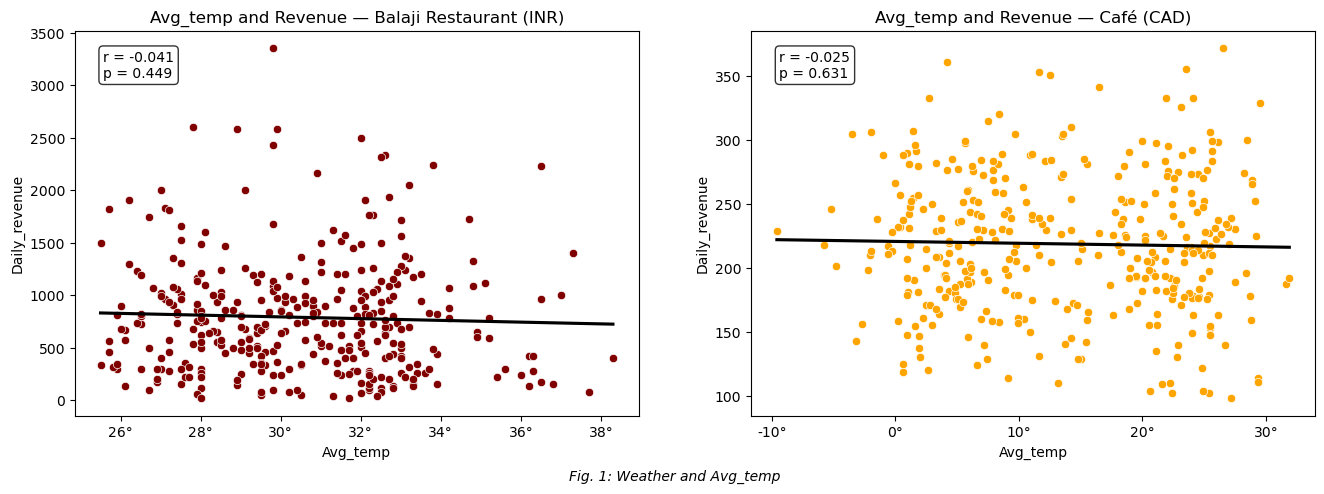

In [30]:
from scipy.stats import pearsonr
# Daily revenue + weather for restaurant
df1_daily = df1_weather.groupby('date').agg(
    Daily_revenue=('transaction_amount', 'sum'),
    Avg_temp=('Max_temp(C°)', 'mean'),
    Precipitation=('P_sum(mm)', 'mean'),
    WMO=('WMO_code', 'first')
).reset_index()

# Daily revenue + weather for café
df2_daily = df2_weather.dropna(subset=['date']).groupby('date').agg(
    Daily_revenue=('Total_spent', 'sum'),
    Avg_temp=('Max_temp(C°)', 'mean'),
    Precipitation=('P_sum(mm)', 'mean'),
    WMO=('WMO_code', 'first')
).reset_index()

#////////////// The above tables can/will be recycled later//////////////
fig, axes = plt.subplots(1,2, figsize = (16,5))
fig.text(0.5, -0.02, 'Fig. 1: Weather and Avg_temp', 
         ha='center', fontsize=10, style='italic')


# data
sp1 = df1_daily
sp2 = df2_daily

# r and p values
r1, p1 = pearsonr(sp1['Avg_temp'], sp1['Daily_revenue'])
r2, p2 = pearsonr(sp2['Avg_temp'], sp2['Daily_revenue'])

#maps
## df1
sns.scatterplot(data=sp1, ax=axes[0], x='Avg_temp', y='Daily_revenue',color='maroon')
sns.regplot(data=sp1,ax=axes[0], x= 'Avg_temp', y='Daily_revenue', 
            scatter=False, color='black',ci=None)

## df2
sns.scatterplot(data=sp2, ax=axes[1], x='Avg_temp', y='Daily_revenue',color='orange')
sns.regplot(data=sp2,ax=axes[1], x= 'Avg_temp', y='Daily_revenue',
            scatter=False, color='black',ci=None)
#labels

axes[0].text(0.05, 0.95, f'r = {r1:.3f}\np = {p1:.3f}',
             transform=axes[0].transAxes, fontsize=10,
             verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
axes[0].set_title('Avg_temp and Revenue — Balaji Restaurant (INR)')
axes[0].set_xlabel('Avg_temp') 
axes[0].set_xticks([26, 28, 30, 32, 34, 36, 38])
axes[0].set_xticklabels(['26°','28°','30°','32°','34°','36°','38°'])

axes[1].text(0.05, 0.95, f'r = {r2:.3f}\np = {p2:.3f}',
             transform=axes[1].transAxes, fontsize=10,
             verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
axes[1].set_title('Avg_temp and Revenue — Café (CAD)')
axes[1].set_xlabel('Avg_temp')
axes[1].set_xticks([-10, 0, 10, 20, 30])
axes[1].set_xticklabels(['-10°','0°','10°','20°','30°']);

Looking at the graphs, daily revenue shows no statistically significant linear correlation with average temperature at either location

**(Restaurant: r = -0.041, p = 0.449; Cafe: r = -0.025, p = 0.631).**

While both correlations are slightly negative and would suggest some relationship, the p-values are well above the 0.05 threshold, meaning these weak associations are likely due to random variation rather than a true underlying pattern. We therefore fail to reject the null hypothesis: temperature alone does not appear to be a meaningful predictor of daily revenue at either location.

#### Weather vs. Revenue
------------


Before mapping, we have to add a new column that has an interpretations of different precipitation values. Note that the cafe's snowy conditions will not be detected by using precipitation since it measures liquid(mm) so for the cafe conditions, we will look at the WMO code for snow and storms

In [6]:
# Conditional values
Rconditions = [
   df1_daily['Precipitation'] == 0,
   (df1_daily['Precipitation'] >0)&(df1_daily['Precipitation']<=5), 
   (df1_daily['Precipitation'] >5)&(df1_daily['Precipitation']<=20), 
   df1_daily['Precipitation']>=20 
]
Cconditions = [
   df2_daily['WMO'].between(71,77),
   df2_daily['WMO'].between(80,99),
   df2_daily['Precipitation'] == 0,
   (df2_daily['Precipitation'] >0)&(df2_daily['Precipitation']<=5), 
   (df2_daily['Precipitation'] >5)&(df2_daily['Precipitation']<=20), 
   df2_daily['Precipitation']>=20 
]
## Labels
Clabels=[
    'Snow',
    'Storm',
    'Dry',
    'Light Rain',
    'Moderate Rain',
    'Heavy Rain',
]
Rlabels= [
    'Dry',
    'Light Rain',
    'Moderate Rain',
    'Heavy Rain',
]
# column
df1_daily['Conditions'] = np.select(Rconditions,Rlabels, default='Unknown')
df2_daily['Conditions'] = np.select(Cconditions,Clabels, default='Unknown')

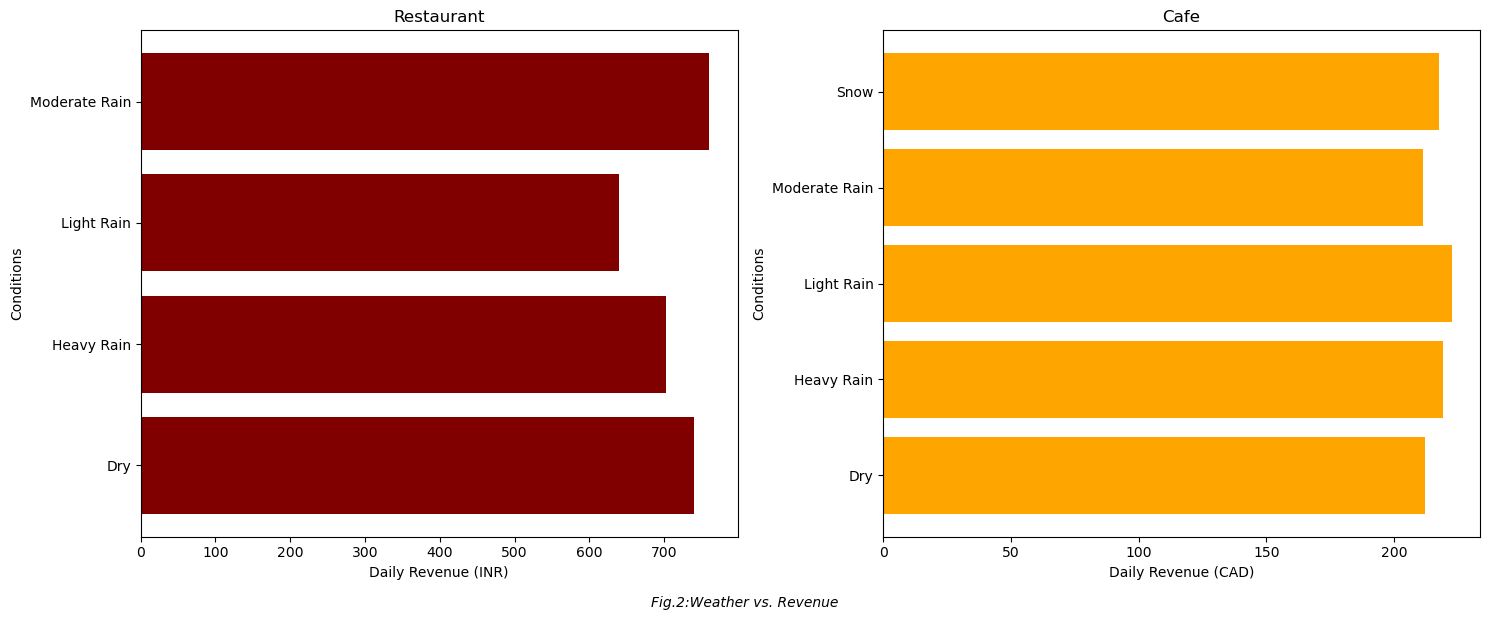

In [22]:
# Aggregating
Cvalues = df2_daily.groupby('Conditions')['Daily_revenue'].median()
Rvalues = df1_daily.groupby('Conditions')['Daily_revenue'].median()

# figs n axes
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 6))
fig.text(0.5, -0.02, 'Fig.2:Weather vs. Revenue', 
         ha='center', fontsize=10, style='italic')
# Restaurant
axes[0].barh(Rvalues.index,Rvalues.values, color ='maroon')
axes[0].set_title('Restaurant')
axes[0].set_xlabel('Daily Revenue (INR)')
axes[0].set_ylabel('Conditions')

# Cafe
axes[1].barh(Cvalues.index,Cvalues.values, color ='orange')
axes[1].set_title('Cafe')
axes[1].set_xlabel('Daily Revenue (CAD)')
axes[1].set_ylabel('Conditions')


plt.tight_layout()
plt.show()

 **Note:** No storm events (WMO 80-99) were recorded in Toronto during 2023 in the Open-Meteo dataset. The Storm category was included in the chart's code but did not appear in this year's data. 

#### Weather vs. Revenue Summary

After analysing two variables, we can strongly say the following about the two stores:

**Restaurant (Mumbai):**
Moderate rain days show the highest median daily revenue, suggesting that light to moderate rainfall does not deter customers at all. This may sugges that Mumbai has a culture of dining out regardless of weather, or that rain drives people indoors to eat out rather than cooking at home.

**Café (Toronto):**
Previously in Phase 2 we also hypothesized that the extreme weather in Canada might have an effect on the cafe revenue —similar to how Diwali was hypothesized to have an impact on restaurant sales—. Here we find that revenue is consistent across all weather conditions — even in snow days. This suggests the café has a loyal, repeat customer base who visits the store regardless of the weather condition.

However it is important to take into account that the cafe has high volume of daily transaction which may smooth out weather effects when median was chosen.

**Overall:** **Weather condition alone is not a strong predictor of revenue for either store** unlike what was hypothesized back in Phase 2: Fig.4. Other factors — such as seasonality, festivities, and day of week — likely play a larger role and will be explored goin further.

### Day of Week Analysis (Cafe)
--------------
Having established that weather conditions and temperature do not significantly drive cafe revenue, we will dig deeper to investigate whether day of week reveals any hidden patterns. Identifying consistent high or low performing days could inform staffing, inventory, and targeted marketing campaigns.

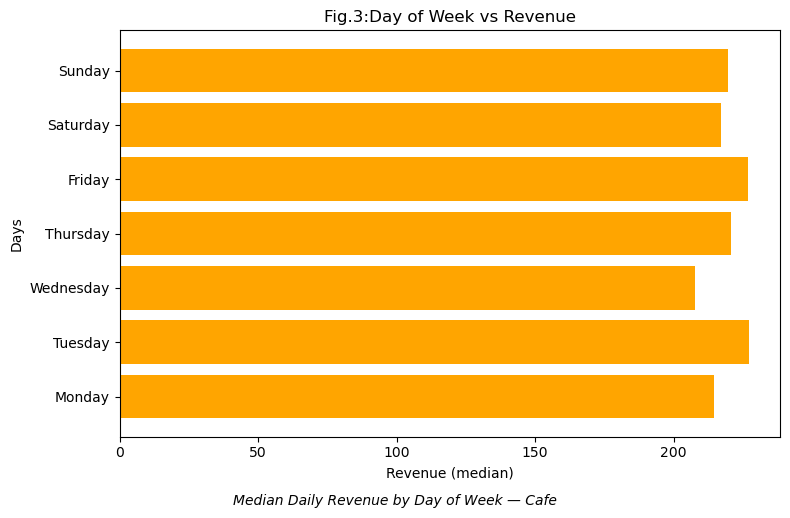

In [8]:
df2_daily['day_of_week'] = df2_daily['date'].dt.day_name()

MdailyR = df2_daily.groupby('day_of_week')['Daily_revenue'].median().reindex([
    'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'
])
# fig n ax
fig, ax = plt.subplots(figsize=(8, 5))
fig.text(0.5, -0.02, 'Median Daily Revenue by Day of Week — Cafe', 
         ha='center', fontsize=10, style='italic')
# Restaurant
ax.set_title('Fig.3:Day of Week vs Revenue')
ax.barh(MdailyR.index,MdailyR.values, color ='orange')
ax.set_xlabel('Revenue (median)')
ax.set_ylabel('Days')

plt.tight_layout()
plt.show()

The revenue distribution across all days of the week are also evened out ranging narrowly from 209(CAD)(Wednesday) to 227(CAD)(Tuesday and Friday). 
Not one single day stands out as a significantly stronger or weaker performer.

Combining this with our earlier findings about weather and temperature confirms that the cafe operates with a stable, loyal customer base whose spending behaviours are not visibly influenced by external factors such as weather conditions, season, or even day of week.

For business strategies, this consistency is actually a good thing — it opens up options like targeted promotions and loyalty programs rather than weather-based marketing strategies. 

## Festivities and Seasonality (Restaurant Only)
----
Here we will analyze the hypothesized effect of Diwali on revenue but before moving on we need to isolate the dates in which diwali occured in 2022. 
#### Note:
After some consideration, Diwali and its effects on revenue will not be reviewed for the cafe. The items sold in the cafe simply do not correlate with Diwali festivities and Indian culture in general so tying Diwali to its sales would be too hypothetical.


In [9]:
# conditional values
Fests = [  
    (df1_daily['date'] >= '2022-10-01') & (df1_daily['date'] <= '2022-10-21'),
    (df1_daily['date'] >= '2022-10-22') & (df1_daily['date'] <= '2022-10-26')
]
Flabels = [
    'Pre-Diwali',
    'Diwali'
]
# column
df1_daily['Diwali_period'] = np.select(Fests, Flabels, default='Normal')
print(df1_daily['Diwali_period'].value_counts())
print('\n',df1_daily[df1_daily['Diwali_period'] == 'Diwali']['date'])

Diwali_period
Normal        323
Pre-Diwali     21
Diwali          4
Name: count, dtype: int64

 193   2022-10-22
194   2022-10-23
195   2022-10-24
196   2022-10-26
Name: date, dtype: datetime64[ns]


After building a new column for Diwali period and knowing that it lasts for 5 days, we can hypothesize that the store might have been closed on one of Diwali days since there was no recorded transactions in Oct. 25 2022.

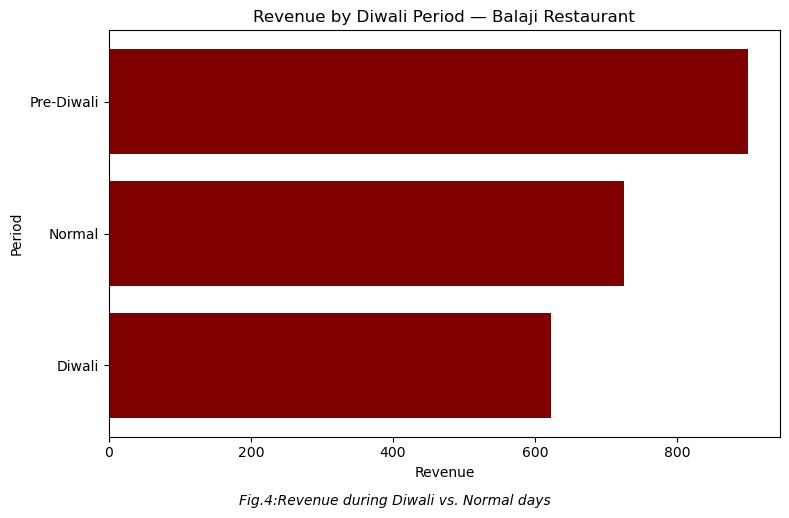

In [10]:
# Aggregating
Dvalues = df1_daily.groupby('Diwali_period')['Daily_revenue'].median()

# figs n axes
fig, ax = plt.subplots(figsize=(8, 5))
fig.text(0.5, -0.02, 'Fig.4:Revenue during Diwali vs. Normal days', 
         ha='center', fontsize=10, style='italic')
# Restaurant
ax.set_title('Revenue by Diwali Period — Balaji Restaurant')
ax.barh(Dvalues.index,Dvalues.values, color ='maroon')
ax.set_xlabel('Revenue')
ax.set_ylabel('Period')

plt.tight_layout()
plt.show()

Here we see surprising patterns. We hypothesized that Diwali might be one of the top drivers of revenue during this season in India. However, **Diwali itself recorded the lowest median daily revenue out of all three observed periods** which directly contradicts our hypothesis. **Instead, while it is in Q4 that Diwali takes place, it is in the Pre-Diwali weeks that people spend more money in the store and not during the week of Diwali.**

This suggests a different customer behaviour than what we hypothesized. The data suggests that the store's customers frontload their spending in the weeks leading up to the festival — likely purchasing food and snacks to enjoy in family celebrations or simply just choosing to stay home — rather than dining out during Diwali itself.

This new-found piece of information will be critical in informing business decisions concerning optimizing inventory and marketing campaigns targeting this specific period. 

## Conclusions
-----
After careful analyis of the impact of weather, temperature and festivities in Mumbai and Toronto, we come to the following conclusions. 

**<span style="color: maroon;">Restaurant</span>**

- Diwali is not the main driver of revenue during Diwali season but the it is the weeks leading up to it.
- Moderately rainy days have somewhat of a positive effect on sales
- Weather does not at all hurt the business
 
**<span style="color: orange;">Cafe</span>**
  
- Revenue is consistent and stable across the whole year
- Weather, season , and/or temperature does not affect the revenue in large scale.
- A loyal customer base can be introduced to loyalty programs and new items can be safely introduced given that it caters to this audience.


## Recommendations
---

### Restaurant
------
The restaurant can benefit from a variety of strategies based on our analysis.

#### Targeted Marketing Campaign

Diwali as we have analyzed, does not greatly affect revenue but the weeks that lead up to it do. If we take advantage of this, we can launch a marketing campaign specifically placed around those weeks and even build a loyal customer base by also introducing loyalty programs. whether it is for dine-in, take-out or online order. 

We also observed that weather may not negatively impact sales which means that we can run campaigns at any season. 

#### Dine-in/Online order promotion

Launching a dine-in promotion can encourage more customers to step into the restaurant and enjoy discounts for their meals. This promotion can also be strategically placed in online delivery apps during rainy days/seasons to help customers enjoy their favorite meals in the comfort of their homes. 

### Cafe
-----
The cafe has a bit more advantage than the restaurant because of its established customer base. This allows for new and bigger options to be explored further.

#### New Items

The cafe already has a stable customer base. We know this because the revenue was stable even during snowfall, rain, or dry days. This means that the business can always explore developing new items that does not deviate far from the flavor that they are known for. 

#### Loyalty program

Introducing a loyalty program is also a good strategy to explore —if they are not already— since the cafe already has a customer base that is generating stable revenue. 

#### Franchising

With enough popularity and a thorough market research on other areas, expanding the business via franchising offers a recurring income from royalty fees and marketing fees. This eventually would allow the owners to explore expanding using their own excess funds. 

## Additional Recommendation
--------


### Item Perfomance
-------------------------------------
Here we are finding items that performs similarly to group up for a bundle. 



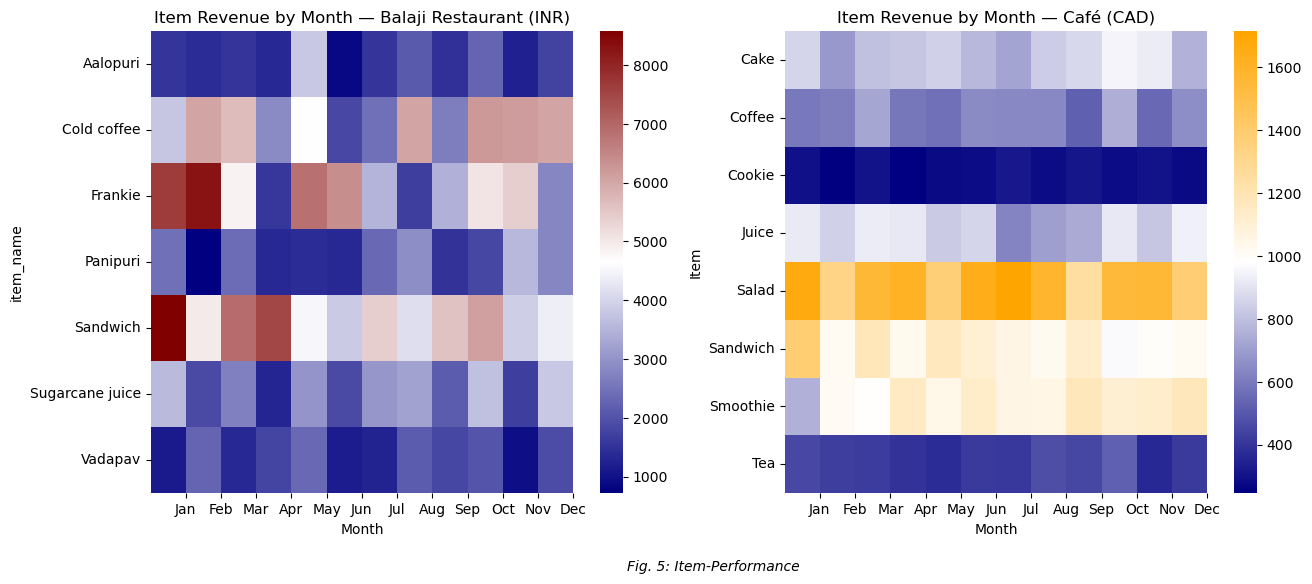

In [12]:
# seeing if data can be properly grouped
#grp = df1.groupby(['item_name',df1['date'].dt.month])['transaction_amount'].sum()
#grp2 = df2.groupby(['Item',df2['date'].dt.month])['Total_spent'].sum()
# print(grp,grp2)

# this gives us the matrix we need
hdf1 = df1.groupby(['item_name', df1['date'].dt.month])['transaction_amount'].sum().unstack()
hdf2 = df2.groupby(['Item', df2['date'].dt.month])['Total_spent'].sum().unstack()

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 6))
fig.text(0.5, -0.02, 'Fig. 5: Item-Performance', 
         ha='center', fontsize=10, style='italic')
# colors
cmap1 = sns.blend_palette(["#000080", "white", "#800000"], as_cmap=True)
cmap2 = sns.blend_palette(["#000080", "white", "#FFA500"], as_cmap=True)

#maps
sns.heatmap(hdf1, ax=axes[0], cmap=cmap1)
sns.heatmap(hdf2, ax=axes[1], cmap=cmap2)

#labels n all
axes[0].set_title('Item Revenue by Month — Balaji Restaurant (INR)')
axes[0].set_xlabel('Month')
axes[0].set_xticks([1,2,3,4,5,6,7,8,9,10,11,12])
axes[0].set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun',
                          'Jul','Aug','Sep','Oct','Nov','Dec']);

axes[1].set_title('Item Revenue by Month — Café (CAD)')
axes[1].set_xlabel('Month')
axes[1].set_xticks([1,2,3,4,5,6,7,8,9,10,11,12])
axes[1].set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun',
                          'Jul','Aug','Sep','Oct','Nov','Dec']);



A couple of suggestions can be made by looking at these maps. High performing items such as Salad, Smoothie,Frankie, Sandwich and Cold Coffee sells above the mean revenue almost throughout the year. But from previous charts we know that this is not purely because the demand for these items are high but because they have a higher price point. So to improve sales, we must think of a strategy that works around our lack of variance in customer basket.


Since we do not have variance in our customer basket data, all we can do is suggest pairings/combos based purely on performance similarities between items. This way we might be able to raise the demand for low performing items up to a decent level without sacrificing profit margin. 



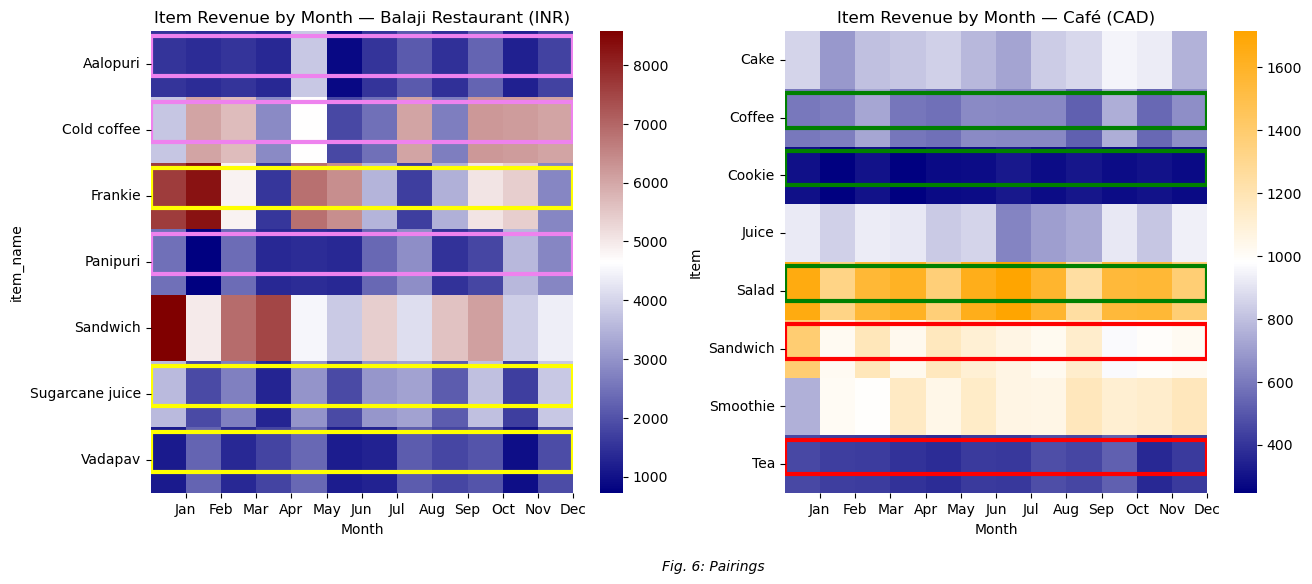

In [29]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 6))
fig.text(0.5, -0.02, 'Fig. 6: Pairings', 
         ha='center', fontsize=10, style='italic')

#-------COLORS--------------------------------------------------------------------

cmap1 = sns.blend_palette(["#000080", "white", "#800000"], as_cmap=True)
cmap2 = sns.blend_palette(["#000080", "white", "#FFA500"], as_cmap=True)

#-------HEATMAPS and LABELS---------------------------------------------------------------------

#maps
sns.heatmap(hdf1, ax=axes[0], cmap=cmap1)
sns.heatmap(hdf2, ax=axes[1], cmap=cmap2)

#labels n all
axes[0].set_title('Item Revenue by Month — Balaji Restaurant (INR)')
axes[0].set_xlabel('Month')
axes[0].set_xticks([1,2,3,4,5,6,7,8,9,10,11,12])
axes[0].set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun',
                          'Jul','Aug','Sep','Oct','Nov','Dec']);

axes[1].set_title('Item Revenue by Month — Café (CAD)')
axes[1].set_xlabel('Month')
axes[1].set_xticks([1,2,3,4,5,6,7,8,9,10,11,12])
axes[1].set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun',
                          'Jul','Aug','Sep','Oct','Nov','Dec']);


#------HIGHLIGHTS---(FOR ITEM-PAIRING)-------------------------------------------------------------

# /////////RESTAURANT INDICES AND PAIRS/////////////////
#indices
Aal_idx = list(hdf1.index).index('Aalopuri')
CC_idx = list(hdf1.index).index('Cold coffee')
Fr_idx = list(hdf1.index).index('Frankie')
PP_idx = list(hdf1.index).index('Panipuri')
SW_idx = list(hdf1.index).index('Sandwich')
ScJ_idx = list(hdf1.index).index('Sugarcane juice')
Vpv_idx = list(hdf1.index).index('Vadapav')

# Rectangular highlighters

### first pair (Vadapav,Sugarcane, and Frankie)
axes[0].add_patch(patches.Rectangle(
    xy=(0, Fr_idx + 0.075),      # (x, y) starting point — x=0 starts at left edge
    width=len(hdf1.columns),  # spans all 12 months
    height= 0.6,                 # one row high
    fill=False,               # just border               
    edgecolor='yellow',       # color              
    linewidth=3              # px                    
))
axes[0].add_patch(patches.Rectangle(
    xy=(0, ScJ_idx + 0.075),                               
    width=len(hdf1.columns),  
    height= 0.6,
    fill=False,                          
    edgecolor='yellow',      
    linewidth=3
))
axes[0].add_patch(patches.Rectangle(
    xy=(0, Vpv_idx + 0.075),      
    width=len(hdf1.columns),  
    height= 0.6,
    fill=False,              
    edgecolor='yellow',      
    linewidth=3        
))

### second pair Aalopuri, panipuri and cold coffee
axes[0].add_patch(patches.Rectangle(
    xy=(0, PP_idx + 0.075),      
    width=len(hdf1.columns),  
    height= 0.6,
    fill=False,              
    edgecolor='violet',      
    linewidth=3  
))
axes[0].add_patch(patches.Rectangle(
    xy=(0, CC_idx + 0.075),      
    width=len(hdf1.columns),  
    height=0.6,
    fill=False,              
    edgecolor='violet',      
    linewidth=3
))
axes[0].add_patch(patches.Rectangle(
    xy=(0, Aal_idx + 0.075),      
    width=len(hdf1.columns),  
    height= 0.6,
    fill=False,              
    edgecolor='violet',      
    linewidth=3
))
# ////////CAFE INDICES AND PAIRS//////////////////////
#indices
Ck_idx = list(hdf2.index).index('Cake')
Cfe_idx = list(hdf2.index).index('Coffee')
Cke_idx = list(hdf2.index).index('Cookie')
Juc_idx = list(hdf2.index).index('Juice')
Sal_idx = list(hdf2.index).index('Salad')
Sah_idx = list(hdf2.index).index('Sandwich')
Smo_idx = list(hdf2.index).index('Smoothie')
Tea_idx = list(hdf2.index).index('Tea')


# Rectangular highlighters
# CAFE PAIR 1 — Salad, Cookie, Coffee (yellow)
axes[1].add_patch(patches.Rectangle(
    xy=(0, Sal_idx + 0.075), 
    width=len(hdf2.columns), 
    height=0.6, 
    fill=False, 
    edgecolor='green', 
    linewidth=3
))
axes[1].add_patch(patches.Rectangle(
    xy=(0, Cke_idx + 0.075), 
    width=len(hdf2.columns), 
    height=0.6, 
    fill=False, 
    edgecolor='green', 
    linewidth=3
))
axes[1].add_patch(patches.Rectangle(
    xy=(0, Cfe_idx + 0.075), 
    width=len(hdf2.columns), 
    height=0.6, 
    fill=False, 
    edgecolor='green', 
    linewidth=3
))

# CAFE PAIR 2 — Sandwich, Tea (black)
axes[1].add_patch(patches.Rectangle(
    xy=(0, Sah_idx + 0.075), 
    width=len(hdf2.columns), 
    height= 0.6, 
    fill=False, 
    edgecolor='red', 
    linewidth=3
))
axes[1].add_patch(patches.Rectangle(
    xy=(0, Tea_idx + 0.075), 
    width=len(hdf2.columns), 
    height= 0.6, 
    fill=False, 
    edgecolor='red', 
    linewidth=3))
;

plt.show()

After carefully looking at items with similar revenue pattern, we come up with 2 groups of bundles for each stores. Those are the following

**<span style="color: maroon;">Restaurant</span>**

**Bundle 1: Frankie + Vadapav + Sugarcane Juice**

**Bundle 2: Aalopuri + Panipuri + Cold Coffee**

**<span style="color: orange;">Cafe</span>**

**Bundle 1: Salad, Cookie and Coffee**

**Bundle 2: Sandwich and Tea**

These suggestions have not been made purely from analytical standpoint but the flavour profile has also been considered as well as protein and caloric content of the meals offering a balance between taste and nutrition.

It is also important to note that items such as Sandwich, Juice, Smoothie, and Cake were not bundled up with anything because of the assumption that these have a high cost-to-make price.  



## Closing Remarks
---
    
These findings alongside the business recommendations above will serve as the foundation for the Phase 4 Power BI Dashboard, where key metrics and insights will be translated into interactive visualizations for stakeholder reporting.